## Disorder Measures Plot

Generates `figures/disorder_measures.png` used in the presentation.

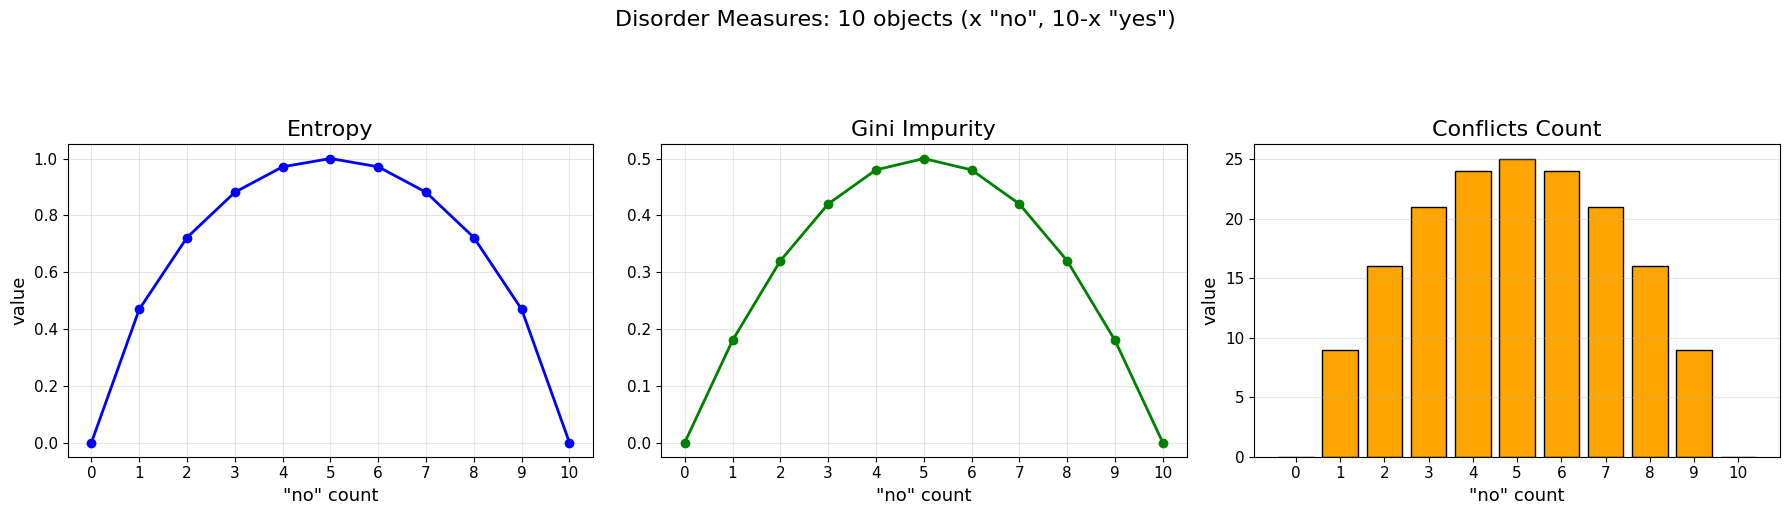

In [1]:
import matplotlib.pyplot as plt
import numpy as np

n = 10
x_vals = np.arange(n + 1)
p = x_vals / n

with np.errstate(divide="ignore", invalid="ignore"):
    entropy_vals = np.where(
        (p > 0) & (p < 1),
        -p * np.log2(p) - (1 - p) * np.log2(1 - p),
        0.0,
    )

gini_vals = 1 - p**2 - (1 - p) ** 2
conflicts_vals = x_vals * (n - x_vals)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(x_vals, entropy_vals, "b-o", linewidth=2, markersize=6)
axes[0].set_title("Entropy", fontsize=16)
axes[0].set_xlabel('"no" count', fontsize=13)
axes[0].set_ylabel("value", fontsize=13)
axes[0].tick_params(labelsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_vals, gini_vals, "g-o", linewidth=2, markersize=6)
axes[1].set_title("Gini Impurity", fontsize=16)
axes[1].set_xlabel('"no" count', fontsize=13)
axes[1].tick_params(labelsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].bar(x_vals, conflicts_vals, color="orange", edgecolor="black")
axes[2].set_title("Conflicts Count", fontsize=16)
axes[2].set_xlabel('"no" count', fontsize=13)
axes[2].set_ylabel("value", fontsize=13)
axes[2].tick_params(labelsize=11)
axes[2].grid(True, alpha=0.3, axis="y")

for ax in axes:
    ax.set_xticks(x_vals)

plt.suptitle('Disorder Measures: 10 objects (x "no", 10-x "yes")', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig("figures/disorder_measures.png", dpi=200, bbox_inches="tight")
plt.show()

## Epsilon Diagram

Generates `figures/epsilon_diagram.png` used in the presentation.

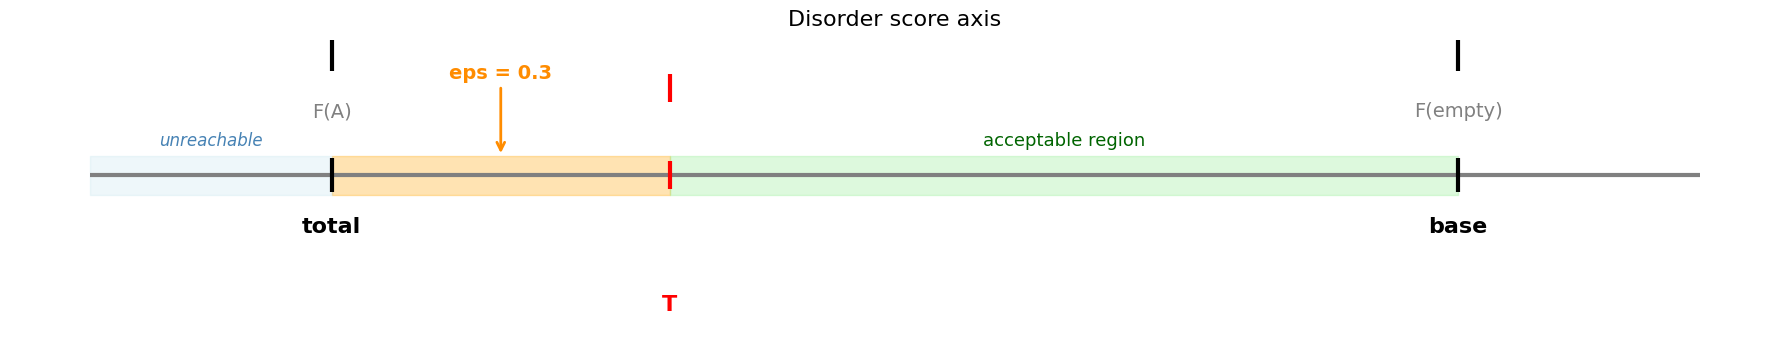

In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(18, 3.5))

total = 0.15
base = 0.85
eps = 0.3
T = total + eps * (base - total)

ax.hlines(y=0, xmin=0, xmax=1, color="gray", linewidth=3)

ax.plot([total, total], [0, 0.25], "k|", markersize=24, markeredgewidth=3)
ax.text(total, -0.12, "total", ha="center", fontsize=16, fontweight="bold")
ax.text(total, 0.12, "F(A)", ha="center", fontsize=14, color="gray")

ax.plot([base, base], [0, 0.25], "k|", markersize=24, markeredgewidth=3)
ax.text(base, -0.12, "base", ha="center", fontsize=16, fontweight="bold")
ax.text(base, 0.12, "F(empty)", ha="center", fontsize=14, color="gray")

ax.plot([T, T], [0, 0.18], "r|", markersize=20, markeredgewidth=3)
ax.text(T, -0.28, "T", ha="center", fontsize=16, color="red", fontweight="bold")

ax.fill_betweenx(
    y=[-0.04, 0.04],
    x1=total,
    x2=T,
    color="orange",
    alpha=0.3,
)
ax.annotate(
    f"eps = {eps}",
    xy=((total + T) / 2, 0.04),
    xytext=((total + T) / 2, 0.2),
    ha="center",
    fontsize=14,
    color="darkorange",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="darkorange", lw=2),
)

ax.fill_betweenx(
    y=[-0.04, 0.04],
    x1=T,
    x2=base,
    color="lightgreen",
    alpha=0.3,
)
ax.text(
    (T + base) / 2,
    0.06,
    "acceptable region",
    ha="center",
    fontsize=13,
    color="darkgreen",
)

ax.fill_betweenx(
    y=[-0.04, 0.04],
    x1=0,
    x2=total,
    color="lightblue",
    alpha=0.2,
)
ax.text(
    total / 2,
    0.06,
    "unreachable",
    ha="center",
    fontsize=12,
    color="steelblue",
    style="italic",
)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.32, 0.28)
ax.axis("off")
ax.set_title("Disorder score axis", fontsize=16, pad=10)

plt.tight_layout()
plt.savefig("figures/epsilon_diagram.png", dpi=200)
plt.show()